In [39]:
import pandas as pd
from collections import defaultdict, Counter
import matplotlib.pyplot as plt
import numpy as np
import random
import inflect


In [2]:
clinical_included_ids_file = "/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/06_preclin_clinic_join/data/clinical/clinical_inlcuded_18609_nctids.csv"
included_nctids = pd.read_csv(clinical_included_ids_file)


### ideas (not yet implemented)
- remove known generics?
- singularize -> cases like "antidepressants" vs "antidepressant"
- would reduce noise

In [128]:
import re

JUNK_PATTERNS = [
    r'^\s*["\']?\s*#?\s*\d+\s*[,"\']?\s*$',  # " 528', '# 0451', '# 2714', 528, 1,234
]

def _is_junk_token(tok: str) -> bool:
    """Return True if token is meaningless junk like '# 0451', '" 528\'', '()', etc."""
    s = tok.strip().strip('"').strip("'").strip()

    # Empty or one-character junk
    if not s or len(s) < 2:
        return True

    # Pure punctuation / brackets / quotes / plus/minus
    if re.fullmatch(r"^[\(\)\[\]\{\}\'\"\,\.\#\s\-\_\+\=]+$", s):
        return True

    # Numeric garbage possibly prefixed/suffixed by punctuation
    if re.fullmatch(r'^[#\s\'\"\(\)\+\-]*\d+[\'\"\)\s,]*$', s):
        return True

    # Hash-prefixed or leading garbage like '# #', '# 0451'
    if s.startswith("#") and not re.search(r"[A-Za-z]", s):
        return True

    # Junk like empty parentheses or stray symbols
    if s in {"()", "( )", "''", '""', "''", "'"}:
        return True

    return False


def clean_predictions(drugs_list: str) -> str:
    """
    Clean and normalize a pipe-separated list of drug names.
    Removes artifacts (like '# # 45-65-nh2', '" 528'), filters mechanistic terms,
    and maps known synonyms to canonical drug names.
    Keeps valid names like 'mir-1192' or 'antagomir-21' intact.
    """
    if not isinstance(drugs_list, str) or not drugs_list.strip():
        return drugs_list

    drug_names = drugs_list.split("|")
    drug_names_clean = set()

    for drug_name in drug_names:
        dn = drug_name.strip().strip('"').strip("'").strip()

        # Junk or meaningless tokens
        if _is_junk_token(dn):
            continue

        # Skip mechanistic/generic category terms
        if any(word in dn.lower() for word in [
            "antibody", "channel", "receptor", "modulator",
            "blocker", "agonist", "antagonis", "anti-", "inhibitor"
        ]):
            continue

        # Canonical name mappings (case-insensitive)
        ln = dn.lower()
        if ln in ["fty720-c2", "fingolimod-1 phosphate"]:
            dn = "Fingolimod"
        elif ln in [
            "1,25-dihydroxyvitamin d", "1alpha,25-dihydroxyvitamin d",
            "vitamin d", "vitamin d3", "calcitriol", "cholecalciferol"
        ]:
            dn = "vitamin D3"
        elif ln in ["beta interferon", "interferon beta (recombinant)"]:
            dn = "beta 1 Interferon"

        # Valid alphanumeric-hyphen pattern (keep mir-1192, agomir-21, etc.)
        if not re.match(r'^[A-Za-z0-9\-\s\(\)]+$', dn):
            continue

        # Too short or empty
        if not dn or len(dn) < 2:
            continue

        drug_names_clean.add(dn)

    # Return cleaned list or fallback to original
    return "|".join(sorted(drug_names_clean)) if drug_names_clean else drugs_list


In [ ]:
#preclinical_df["merged_umls_label_manual_clean"] = preclinical_df['merged_umls_label'].apply(lambda x: clean_predictions(x))

#n_unique, freq = count_unique_from_pipe_column(preclinical_df, "merged_umls_label_manual_clean")
#print(f"Unique count: {n_unique}")

## code for stats

In [3]:
import pandas as pd

def add_unique_entity_count(
    df: pd.DataFrame,
    col: str,
    *,
    sep: str = "|",
    case_insensitive: bool = True,
    new_col: str | None = None,
) -> pd.DataFrame:
    """
    Add a column counting unique entities per row from a pipe-separated column.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe.
    col : str
        Column containing pipe-separated entities.
    sep : str, default "|"
        Separator used in the column.
    case_insensitive : bool, default True
        Whether to normalize entities to lowercase before counting.
    new_col : str, optional
        Name of the new column. Defaults to `{col}_unique_count`.

    Returns
    -------
    pd.DataFrame
        Copy of dataframe with the added unique-count column.
    """
    df = df.copy()
    out_col = new_col or f"{col}_unique_count"

    def count_unique(val):
        if pd.isna(val):
            return 0
        items = [
            v.strip().lower() if case_insensitive else v.strip()
            for v in str(val).split(sep)
            if v.strip()
        ]
        return len(set(items))

    df[out_col] = df[col].apply(count_unique)
    return df


In [4]:
def no_linked_entities(termids: str) -> bool:
    """
    Return True if NONE of the entities were linked.
    Condition:
      - all values == '-1'
      - or empty / None / whitespace
    """
    if not termids:  # None or empty string
        return True
    
    # Split and clean
    parts = [p.strip() for p in str(termids).split("|") if p.strip()]

    if not parts:
        return True  # nothing there → no linked entities

    # True only if every part is '-1'
    return all(p == "-1" for p in parts)


In [62]:
def _split_terms(val, *, sep="|"):
    """Split a sep-joined cell into stripped, non-empty tokens."""
    if val is None:
        return []
    return [t.strip() for t in str(val).split(sep) if t and t.strip()]

def _to_singular_word(word: str) -> str:
    """Singularize a single word safely."""
    if not word:
        return word
    try:
        s = _inflect.singular_noun(word)
    except TypeError:
        return word
    return s if isinstance(s, str) and s else word

def _to_singular(text: str) -> str:
    """
    Singularize only the last whitespace token.
    This is safer than passing full multi-word terms into inflect.
    """
    if not text:
        return text
    parts = text.split()
    if not parts:
        return text
    parts[-1] = _to_singular_word(parts[-1])
    return " ".join(parts)

def _norm_term(
    t: str,
    *,
    case_insensitive: bool,
    singularize: bool = False,
):
    t = "" if t is None else str(t).strip()
    if case_insensitive:
        t = t.lower()
    if singularize and t:
        t = _to_singular(t)
    return t

def _valid_term(t: str, *, ignore_short: bool):
    return (len(t) > 2) if ignore_short else True

def _unique_terms(
    series: pd.Series,
    *,
    sep="|",
    case_insensitive=True,
    singularize=False,
    ignore_short=True,
) -> set:
    out = set()
    for cell in series.fillna(""):
        for t in _split_terms(cell, sep=sep):
            t = _norm_term(t, case_insensitive=case_insensitive, singularize=singularize)
            if _valid_term(t, ignore_short=ignore_short):
                out.add(t)
    return out

def clean_pipe_split(
    s,
    sep: str = "|",
    *,
    case_insensitive: bool = True,
    singularize: bool = False,
    ignore_short_entities: bool = False,
):
    toks = _split_terms(s, sep=sep)
    out = []
    for t in toks:
        t = _norm_term(t, case_insensitive=case_insensitive, singularize=singularize)
        if not t:
            continue
        if ignore_short_entities and not _valid_term(t, ignore_short=True):
            continue
        out.append(t)
    return out

def _split_raw(s, sep="|"):
    return [t.strip() for t in str(s or "").split(sep) if t and t.strip()]


In [63]:
def summarize_entity_mappings(
    df,
    norm_col: str,
    id_col: str,
    ner_col: str,
    doc_id_col: str = "PMID",
    ignore_id: str = "-1",
    ignore_short_entities: bool = True,
    *,
    sep: str = "|",
    case_insensitive: bool = True,
    singularize: bool = False,
):
    unique_entities_with_mappings = {}
    entity_frequency = defaultdict(int)
    mapped_to_ner = defaultdict(set)

    for _, row in df.iterrows():
        doc_id = row.get(doc_id_col, "")

        # split-only for alignment
        norm_raw = _split_raw(row.get(norm_col), sep=sep)
        ids_raw  = _split_raw(row.get(id_col),  sep=sep)
        ner_raw  = _split_raw(row.get(ner_col), sep=sep)

        # names vs ids must align (RAW)
        if len(norm_raw) != len(ids_raw):
            print(f"ERROR (names vs mappings length) {doc_id_col} {doc_id}")
            print(f"  {norm_col}: {norm_raw}")
            print(f"  {id_col}  : {ids_raw}")
            continue

        # normalize/filter AFTER alignment, inside the zip
        norm_vals = []
        id_vals = []
        for ent, mid in zip(norm_raw, ids_raw):
            ent_n = _norm_term(ent, case_insensitive=case_insensitive, singularize=singularize)
            mid = mid.strip()
            if not ent_n:
                continue
            if ignore_short_entities and len(ent_n) <= 2:
                continue
            norm_vals.append(ent_n)
            id_vals.append(mid)

            unique_entities_with_mappings.setdefault(ent_n, mid)
            entity_frequency[ent_n] += 1

        # names vs NER alignment is optional; check RAW to avoid false notes
        if len(norm_raw) != len(ner_raw):
            print(
                f"NOTE (names vs NER length) {doc_id_col} {doc_id}:\n"
                f"  → {len(norm_raw)} names vs {len(ner_raw)} NER tokens\n"
                f"  names: {norm_raw}\n"
                f"  ner  : {ner_raw}\n"
            )
            continue

        # mapped_to_ner: align RAW triples, then normalize/filter
        for ent, mid, ner_tok in zip(norm_raw, ids_raw, ner_raw):
            ent_n = _norm_term(ent, case_insensitive=case_insensitive, singularize=singularize)
            ner_n = _norm_term(ner_tok, case_insensitive=case_insensitive, singularize=singularize)
            mid = mid.strip()
            if not ent_n:
                continue
            if ignore_short_entities and len(ent_n) <= 2:
                continue
            if mid != ignore_id and ner_n:
                key = f"{ent_n} ({mid})"
                mapped_to_ner[key].add(ner_n)

    mapped_to_ner_df = (
        pd.DataFrame(
            [
                {
                    "entity_mapping": key,
                    "entity": key.split("(")[0].strip(),
                    "mapping": key.split("(")[1].rstrip(")").strip(),
                    "ner_tokens": sorted(values),
                    "ner_count": len(values),
                }
                for key, values in mapped_to_ner.items()
            ]
        )
        .sort_values(by="ner_count", ascending=False)
        .reset_index(drop=True)
    )

    return unique_entities_with_mappings, entity_frequency, mapped_to_ner, mapped_to_ner_df


In [118]:

def entity_linking_report(
    df: pd.DataFrame,
    *,
    norm_col: str,
    id_col: str,
    ner_col: str,
    parent_label_col: str,
    clean_label_col: str | None = None,
    doc_id_col: str = "PMID",
    ignore_id: str = "-1",
    sep: str = "|",
    case_insensitive: bool = True,
    singularize: bool = False,
    round_digits: int = 2,
    ignore_short_entities: bool = True,
):
    # detailed summary on normalized entities
    unique_norm_to_id, norm_freq, mapped_to_ner, mapped_to_ner_df = summarize_entity_mappings(
        df=df,
        norm_col=norm_col,
        id_col=id_col,
        ner_col=ner_col,
        doc_id_col=doc_id_col,
        ignore_id=ignore_id,
        ignore_short_entities=ignore_short_entities,
        singularize=singularize
    )

    if ignore_short_entities:
        print("Only entities with more than 2 characters are considered.")
    if singularize:
        print("Inflecting to singular forms.")

    # unique counts (raw, linked, linked+parent, optional clean)
    raw_set    = _unique_terms(df[ner_col],          sep=sep, case_insensitive=case_insensitive, singularize=singularize, ignore_short=ignore_short_entities)
    linked_set = _unique_terms(df[norm_col],         sep=sep, case_insensitive=case_insensitive, singularize=singularize, ignore_short=ignore_short_entities)
    parent_set = _unique_terms(df[parent_label_col], sep=sep, case_insensitive=case_insensitive, singularize=singularize, ignore_short=ignore_short_entities)

    count_unique_raw = len(raw_set)
    count_unique_linked = len(linked_set)
    count_unique_with_parent = len(parent_set)

    count_unique_clean = None
    if clean_label_col and clean_label_col in df.columns:
        clean_set = _unique_terms(df[clean_label_col], sep=sep, case_insensitive=case_insensitive, ignore_short=ignore_short_entities)
        count_unique_clean = len(clean_set)

    # --- linking success computed from RAW tokens aligned with IDs ---
    raw_freq = Counter()        # raw -> mentions
    raw_to_first_id = {}        # raw -> first id at same position
    mismatch_rows = 0

    for row in df[[ner_col, id_col]].itertuples(index=False, name=None):
        raw_cell, id_cell = row
        raw_vals = _split_terms(raw_cell, sep=sep)
        id_vals  = _split_terms(id_cell,  sep=sep)

        if len(raw_vals) != len(id_vals):
            mismatch_rows += 1

        for raw, mid in zip(raw_vals, id_vals):
            raw_key = _norm_term(raw, case_insensitive=case_insensitive, singularize=singularize)
            if not _valid_term(raw_key, ignore_short=ignore_short_entities):
                continue
            raw_freq[raw_key] += 1
            raw_to_first_id.setdefault(raw_key, mid)

    total_mentions = sum(raw_freq.values())

    # unique raw terms that map to a real ID
    mapped_unique_raw = sum(1 for mid in raw_to_first_id.values() if mid != ignore_id)

    # mentions whose (first-seen) ID is not ignore_id
    mapped_mentions = sum(
        freq for raw_key, freq in raw_freq.items()
        if raw_to_first_id.get(raw_key, ignore_id) != ignore_id
    )

    pct_mapped_unique = (mapped_unique_raw / count_unique_raw * 100) if count_unique_raw else 0.0
    pct_mapped_mentions = (mapped_mentions / total_mentions * 100) if total_mentions else 0.0

    report_row = {
        "total mentions": total_mentions,
        "count unique raw entities": count_unique_raw,
        "count unique linked entities": count_unique_linked,
        "count unique linked with parent": count_unique_with_parent,
        "Linking success (unique / % mapped freq adjusted)": (
            f"{mapped_unique_raw} ({round(pct_mapped_unique, round_digits)}%)/"
            f"{count_unique_raw} ({round(pct_mapped_mentions, round_digits)}%)"
        ),
        "mismatch rows (raw vs id length)": mismatch_rows,
    }

    if count_unique_clean is not None:
        report_row["count unique clean labels"] = count_unique_clean # MONDO entities had an extra post-processing step

    report = pd.DataFrame([report_row])

    details = {
        "unique_norm_to_id": unique_norm_to_id,
        "norm_frequency": norm_freq,
        "mapped_to_ner": mapped_to_ner,
        "mapped_to_ner_df": mapped_to_ner_df,
        "raw_frequency": raw_freq,
        "raw_to_first_id": raw_to_first_id,
    }

    return report, details


In [55]:
def top_mapped_unmapped_side_by_side(
    unique_entities_with_mappings: dict,
    entity_frequency: dict,
    *,
    entity_name: str = "entity",
    unmapped_id: str = "-1",
    top_n: int = 10,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Build a frequency table for entities, then return top-N mapped and unmapped
    entities side-by-side.

    Parameters
    ----------
    unique_entities_with_mappings : dict
        entity -> mapping_id (first seen mapping)
    entity_frequency : dict
        entity -> frequency / mentions
    entity_name : str
        Label used for the entity column in outputs (e.g. 'drug', 'disease')
    unmapped_id : str
        Value representing no mapping (default '-1')
    top_n : int
        Number of top mapped/unmapped to return

    Returns
    -------
    entity_df : DataFrame
        Full entity table: [entity, mapping, frequency, is_mapped]
    mapped_top : DataFrame
        Top-N mapped entities by frequency
    unmapped_top : DataFrame
        Top-N unmapped entities by frequency
    side_by_side : DataFrame
        Two tables concatenated horizontally: mapped vs unmapped
    """
    # Full table
    entity_df = pd.DataFrame([
        {
            entity_name: ent,
            "mapping": unique_entities_with_mappings.get(ent),
            "frequency": int(entity_frequency.get(ent, 0)),
        }
        for ent in unique_entities_with_mappings.keys()
    ])

    entity_df["is_mapped"] = entity_df["mapping"].astype(str).str.strip().ne(unmapped_id)

    entity_df = entity_df.sort_values(by="frequency", ascending=False).reset_index(drop=True)

    mapped_top = (
        entity_df[entity_df["is_mapped"]]
        .sort_values(by="frequency", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )

    unmapped_top = (
        entity_df[~entity_df["is_mapped"]]
        .sort_values(by="frequency", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )

    side_by_side = pd.concat(
        [
            mapped_top[[entity_name, "frequency"]].rename(
                columns={entity_name: f"Mapped {entity_name.title()}", "frequency": "Mapped Freq"}
            ),
            unmapped_top[[entity_name, "frequency"]].rename(
                columns={entity_name: f"Unmapped {entity_name.title()}", "frequency": "Unmapped Freq"}
            ),
        ],
        axis=1,
    )

    return entity_df, mapped_top, unmapped_top, side_by_side


In [56]:
def summarize_entities_per_document(
    df: pd.DataFrame,
    col: str,
    round_digits: int = 2,
):
    """
    Compute mean and standard deviation of unique entities per document.

    Returns
    -------
    dict with mean, std, min, max
    """
    return {
        "mean": round(df[col].mean(), round_digits),
        "std": round(df[col].std(), round_digits),
        "median": round(df[col].median(), round_digits),
        "min": int(df[col].min()),
        "max": int(df[col].max()),
    }


In [57]:
def pct_nonlinked_singletons(entity_counter, mapping_lookup):
    """
    Percentage of non-linked entities that appear only once.
    """

    # all non-linked entities
    nonlinked = [
        e for e, m in mapping_lookup.items()
        if str(m).strip() == "-1"
    ]

    if not nonlinked:
        return 0.0, 0, 0

    # among them, those that appear exactly once
    nonlinked_singletons = [
        e for e in nonlinked
        if entity_counter.get(e, 0) == 1
    ]

    pct = (len(nonlinked_singletons) / len(nonlinked)) * 100

    return pct, len(nonlinked_singletons), len(nonlinked)

def raw_frequencies_stats(drug_details, *, seed: int = 42, n_examples: int = 10, n_bins: int = 20):
    entity_counter = drug_details["raw_frequency"]
    mapping_lookup = drug_details["raw_to_first_id"]

    freqs = np.array(list(entity_counter.values()), dtype=int)

    n_total = len(freqs)
    n_singletons = int(np.sum(freqs == 1))
    pct_singletons = (n_singletons / n_total) * 100 if n_total > 0 else 0.0

    print(f"Entities appearing once: {n_singletons:,}")
    print(f"Total unique entities: {n_total:,}")
    print(f"Percentage singletons: {pct_singletons:.2f}%")

    # --- singleton list ---
    singletons = [entity for entity, freq in entity_counter.items() if int(freq) == 1]

    # --- % of singletons that are linked ---
    def _is_linked(e):
        mid = mapping_lookup.get(e, "-1")
        return str(mid).strip() != "-1"

    n_singletons_linked = sum(_is_linked(e) for e in singletons)
    pct_singletons_linked = (n_singletons_linked / len(singletons) * 100) if singletons else 0.0

    pct, n_singletons_nonlinked, n_nonlinked = pct_nonlinked_singletons(
    entity_counter, mapping_lookup
    )
    
    print(
        f"Non-linked entities appearing once: "
        f"{n_singletons_nonlinked:,} / {n_nonlinked:,} "
        f"({pct:.2f}%)"
    )
    print(f"Singletons linked: {n_singletons_linked:,} / {len(singletons):,} "
          f"({pct_singletons_linked:.2f}%)")

    # --- length of one list ---
    length_max = 3
    short_entities = [entity for entity, freq in entity_counter.items() if len(entity) < length_max]
    n_shorts_linked = sum(_is_linked(e) for e in short_entities)
    pct_shorts_linked = (n_shorts_linked / len(short_entities) * 100) if short_entities else 0.0

    print(f"Entities of length smaller than {length_max}: {len(short_entities)} ")
    print(f"Short entities linked: {n_shorts_linked:,} / {len(short_entities):,} "
          f"({pct_shorts_linked:.2f}%)")

    # --- shuffled examples ---
    rng = random.Random(seed)
    shuffled_singletons = singletons.copy()
    rng.shuffle(shuffled_singletons)

    print("Example singleton entities:")
    for e in shuffled_singletons[:min(n_examples, len(shuffled_singletons))]:
        print(f" - {e} mapped to {mapping_lookup.get(e, '-1')}")

    print("Example short entities:")
    for e in short_entities[:15]:
        print(f" - {e}")

    # --- integer-aligned log bins (avoid 1–1 duplicates + plot gaps) ---
    fmin, fmax = int(freqs.min()), int(freqs.max())
    raw_bins = np.logspace(np.log10(fmin), np.log10(fmax), n_bins)
    edges = np.unique(np.round(raw_bins).astype(int))
    edges = edges[edges > 0]
    edges[0] = 1
    edges = np.append(edges, fmax + 1)

    hist, edges = np.histogram(freqs, bins=edges)

    for i in range(len(hist)):
        print(f"{edges[i]}–{edges[i+1]}: {int(hist[i])}")

    plt.figure(figsize=(6, 4))
    plt.hist(freqs, bins=edges)
    plt.xscale("log")
    plt.xlabel("Entity frequency (log scale)")
    plt.ylabel("Number of entities")
    plt.tight_layout()
    plt.show()

## Drug Entities

In [11]:
clinical_drugs="/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/04_normalization/data/mapped_all/mapped_clinical_drug_data_with_umls_parents.csv"
preclinical_drugs="/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/04_normalization/data/mapped_all/mapped_preclinical_drug_data_with_umls_parents.csv"

In [12]:
df_drugs_cli = pd.read_csv(clinical_drugs)
df_drugs_cli = df_drugs_cli[df_drugs_cli['nct_id'].isin(included_nctids['nct_id'])]
df_drugs_cli.shape

(18609, 11)

In [13]:
df_drugs_pre = pd.read_csv(preclinical_drugs)
df_drugs_pre.shape

(540999, 11)

### preclinical

In [14]:
doc_id_col = "PMID"
drug_raw_entities_col = "unique_interventions_linkbert_predictions"

drug_linked_entities_col = "drug_umls_term_norm"
drug_linked_entities_ids = "drug_umls_termid"

drug_parent_entities_col = "nearest_dataset_parent_umls_label"
drug_with_parents_entities_col = "merged_umls_label"
drug_with_parents_entities_ids = "merged_umls_termid"

cols_to_keep = [
    doc_id_col,
    drug_raw_entities_col,
    drug_linked_entities_col,
    drug_linked_entities_ids,
    drug_parent_entities_col,
    drug_with_parents_entities_col,
    drug_with_parents_entities_ids,
]

df_to_analyse_drug_preclin = df_drugs_pre[cols_to_keep].copy()
df_to_analyse = df_to_analyse_drug_preclin.copy()
df_to_analyse.head()

,PMID,unique_interventions_linkbert_predictions,drug_umls_term_norm,drug_umls_termid,nearest_dataset_parent_umls_label,merged_umls_label,merged_umls_termid
0,31733831,isorhynchophylline,isorhynchophylline,C0245133,-1,isorhynchophylline,C0245133
1,31733833,mir-1192|antgomir-1192|agomir-1192,"MIRN1192 microRNA, mouse|antgomir-1192|agomir-...",C3849422|-1|-1,-1,"MIRN1192 microRNA, mouse|antgomir-1192|agomir-...",C3849422|-1|-1
2,31733925,hla-g2|g2,HLA-G2 Isoform|g2,C0967254|-1,-1,HLA-G2 Isoform|g2,C0967254|-1
3,31733940,minocycline,Minocycline,C0026187,-1,Minocycline,C0026187
4,31734027,tadalafil|phosphodiesterase type 5 inhibitor t...,Tadalafil|Tadalafil,C1176316|C1176316,-1,Tadalafil,C1176316


In [15]:
df_to_analyse["no_valid_mapping"] = (
    df_to_analyse["drug_umls_termid"].apply(no_linked_entities)
)
perc_no_mapping_at_all = df_to_analyse.no_valid_mapping.sum()/len(df_to_analyse)*100
df_to_analyse.no_valid_mapping.sum(), 100 - perc_no_mapping_at_all

(42797, 92.08926449032253)

In [16]:
df_to_analyse = add_unique_entity_count(
    df_to_analyse,
    col="merged_umls_label"
)
summary = summarize_entities_per_document(
    df_to_analyse,
    col="merged_umls_label_unique_count"
)

summary

{'mean': 2.7, 'std': 2.16, 'median': 2.0, 'min': 1, 'max': 44}

In [50]:
drug_report_preclin, drug_details_preclin = entity_linking_report(
    df=df_to_analyse,
    ner_col="unique_interventions_linkbert_predictions",  # raw
    norm_col="drug_umls_term_norm",                       # linked labels
    id_col="drug_umls_termid",                            # linked ids (aligned)
    parent_label_col="merged_umls_label",                 # linked + parent labels
    doc_id_col="PMID",
    singularize=True
)
drug_report_preclin


Only entities with more than 2 characters are considered.
Inflecting to singular forms.


,total mentions,count unique raw entities,count unique linked entities,count unique linked with parent,Linking success (unique / % mapped freq adjusted),mismatch rows (raw vs id length)
0,1495318,407039,278660,278680,186069 (45.71%)/407039 (70.75%),0


In [98]:
drug_report_preclin, drug_details_preclin = entity_linking_report(
    df=df_to_analyse,
    ner_col="unique_interventions_linkbert_predictions",  # raw
    norm_col="drug_umls_term_norm",                       # linked labels
    id_col="drug_umls_termid",                            # linked ids (aligned)
    parent_label_col="merged_umls_label",                 # linked + parent labels
    doc_id_col="PMID",
    singularize=False
)
drug_report_preclin

Only entities with more than 2 characters are considered.


,total mentions,count unique raw entities,count unique linked entities,count unique linked with parent,Linking success (unique / % mapped freq adjusted),mismatch rows (raw vs id length)
0,1499728,425284,291436,291457,190987 (44.91%)/425284 (70.67%),0


#### sanity check 

In [92]:
def build_termid_mapping(df, term_col="merged_umls_label", id_col="merged_umls_termid", sep="|"):
    # Split into lists
    terms = (
        df[term_col]
        .fillna("")
        .astype(str)
        .str.split(sep)
        .apply(lambda lst: [x.strip() for x in lst if x.strip()])
    )
    ids   = df[id_col].fillna("").astype(str).str.split(sep)
    mismatch_count=0
    # Build a long table: one row per (term, termid) pair, aligned by index within the split lists
    rows = []
    for row_terms, row_ids in zip(terms, ids):
        if len(row_terms) != len(row_ids):
            print(f"ISSSUE {row_terms} {row_ids}")
            mismatch_count += 1
     
        # align by position (zip truncates to shortest; optionally handle mismatches below)
        for t, i in zip(row_terms, row_ids):
            t = t.strip()
            i = i.strip()
            if len(t) <= 2:
                continue
            rows.append((t, i))

    long = pd.DataFrame(rows, columns=["term", "termid"])

    mapping = long.set_index("term")["termid"].to_dict() 

    # Also return the full unique pairs table (useful if some terms map to multiple ids)
    return mapping, long

In [93]:
mapping,long = build_termid_mapping(df_to_analyse, term_col="unique_interventions_linkbert_predictions", id_col="drug_umls_termid")

In [96]:
total = len(mapping)
num_minus_one = sum(v == '-1' for v in mapping.values())

percent_minus_one = (num_minus_one / total) * 100

print(f"{percent_minus_one:.2f}%")

55.09%


In [94]:
len(mapping)


425284

In [23]:
drug_details_preclin.keys()

dict_keys(['unique_norm_to_id', 'norm_frequency', 'mapped_to_ner', 'mapped_to_ner_df', 'raw_frequency', 'raw_to_first_id'])

In [24]:
drug_details_preclin['mapped_to_ner_df'].to_csv("data/preclin_drug_entity_mapping.csv", index=False)

In [25]:
with open("data/entity_mapping.json", "w") as f:
    json.dump(drug_details_preclin['raw_to_first_id'], f, indent=2)

#### check singletons

Entities appearing once: 325,406
Total unique entities: 425,284
Percentage singletons: 76.51%
Non-linked entities appearing once: 192,696 / 234,297 (82.24%)
Singletons linked: 132,710 / 325,406 (40.78%)
Entities of length smaller than 3: 0 
Short entities linked: 0 / 0 (0.00%)
Example singleton entities:
 - glucagon-like peptide receptor (glp-1r) agonists mapped to C1562104
 - # # 2a mapped to -1
 - qt-loaded mapped to -1
 - na (+) channel opener mapped to -1
 - sevo sevoflurane mapped to C0074414
 - 1 , 4-bis-[n-(buta-2 , 3-dienyl) amino] butane mapped to -1
 - fk687 mapped to -1
 - chalcone-dithiocarbamates mapped to -1
 - alpha-defensins 1 3 mapped to -1
 - lademirsen anti-mir-21 mapped to -1
Example short entities:
1–2: 325406
2–4: 58876
4–6: 14743
6–10: 10516
10–15: 4999
15–24: 3909
24–38: 2497
38–60: 1594
60–95: 1014
95–149: 637
149–235: 434
235–371: 290
371–585: 188
585–922: 83
922–1454: 58
1454–2292: 26
2292–3613: 10
3613–5696: 3
5696–5697: 1


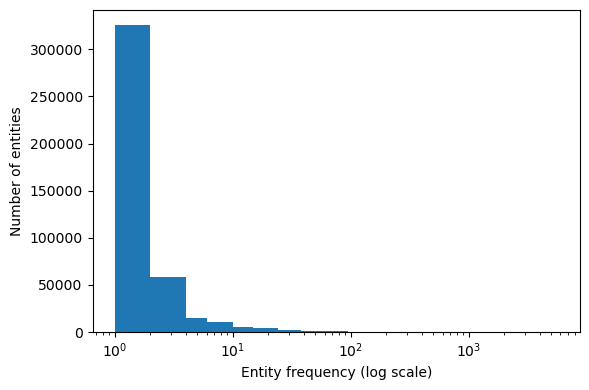

In [99]:
raw_frequencies_stats(drug_details_preclin)

In [100]:
drug_details_preclin.keys()

dict_keys(['unique_norm_to_id', 'norm_frequency', 'mapped_to_ner', 'mapped_to_ner_df', 'raw_frequency', 'raw_to_first_id'])

In [101]:
mapped_drugs_to_ner_df = drug_details_preclin["mapped_to_ner_df"]
mapped_drugs_to_ner_df

,entity_mapping,entity,mapping,ner_tokens,ner_count
0,ng-nitroarginine methyl ester (C0083536),ng-nitroarginine methyl ester,C0083536,"[()-nitro-l-arginine methyl ester, (d)-nitro-l...",761
1,glucagon-like peptide 1 receptor agonist (C156...,glucagon-like peptide 1 receptor agonist,C1562104,"[(glp-1r) agonists, acting glp-2 analogs, acti...",346
2,"3 inhibitor, phosphodiesterase (C2267032)","3 inhibitor, phosphodiesterase",C2267032,"[(pde) inhibitors, 3'-5'-cyclic adenosine mono...",315
3,mk-801 (C0813872),mk-801,C0813872,"[(+ /-) mk-801, (+) mk-801, (+) mk801, (+))-mk...",294
4,histone deacetylase inhibitor (C1512474),histone deacetylase inhibitor,C1512474,[1 isoform-selective histone deacetylase inhib...,292
...,...,...,...,...,...
57161,"cyclin-dependent kinase 12 protein, human (C16...","cyclin-dependent kinase 12 protein, human",C1620114,[cdk12],1
57162,norcocaethylene (C0655454),norcocaethylene,C0655454,[norcocaethylene],1
57163,"complement c3u protein, human (C1437780)","complement c3u protein, human",C1437780,[c3u],1
57164,sr 31747a (C0380238),sr 31747a,C0380238,[sr 31747a],1


In [102]:
mapped_drugs_to_ner_df.to_csv("./data/linked_drugs_preclinical.csv", index=False)

In [103]:
drug_df, mapped_top10, unmapped_top10, side_by_side = top_mapped_unmapped_side_by_side(
    drug_details_preclin["unique_norm_to_id"],
    drug_details_preclin["norm_frequency"],
    entity_name="drug",
    unmapped_id="-1",
    top_n=10,
)

side_by_side


,Mapped Drug,Mapped Freq,Unmapped Drug,Unmapped Freq
0,ng-nitroarginine methyl ester,6609,inhibitor,1308
1,dexamethasone,6048,inhibitors,868
2,acetylcysteine,5452,antagonists,673
3,cyclosporine,4995,antagonist,577
4,cisplatin,4474,no donor,564
5,sirolimus,4392,selective serotonin reuptake inhibitor,540
6,doxorubicin,4076,ssris,517
7,melatonin,3856,selective serotonin reuptake inhibitors,508
8,estradiol,3725,pi3k inhibitor,498
9,glucocorticoids,3688,tyrosine kinase inhibitor,486


### clinical

In [104]:
doc_id_col = "nct_id"

cols_to_keep = [
    doc_id_col,
    drug_raw_entities_col,
    drug_linked_entities_col,
    drug_linked_entities_ids,
    drug_parent_entities_col,
    drug_with_parents_entities_col,
    drug_with_parents_entities_ids,
]
df_to_analyse_cli_drugs = df_drugs_cli[cols_to_keep].copy()
df_to_analyse_cli = df_to_analyse_cli_drugs.copy()
df_to_analyse_cli.head()

,nct_id,unique_interventions_linkbert_predictions,drug_umls_term_norm,drug_umls_termid,nearest_dataset_parent_umls_label,merged_umls_label,merged_umls_termid
0,NCT03502551,ketamine,Ketamine,C0022614,-1,Ketamine,C0022614
1,NCT05216770,Laryngeal sensory block with topical bupivacaine,Laryngeal sensory block with topical bupivacaine,-1,-1,Laryngeal sensory block with topical bupivacaine,-1
2,NCT03348735,lidocaine|capsaicin|Lidocaine patch 5%,Lidocaine|Capsaicin|lidocaine 0.05 MG/MG Medic...,C0023660|C0006931|C0794811,-1,Lidocaine|Capsaicin|lidocaine 0.05 MG/MG Medic...,C0023660|C0006931|C0794811
3,NCT05995600,clopidogrel|warfarin|aspirin|Antiplatelet Drug,clopidogrel|Warfarin|Aspirin|Antiplatelet Drug,C0070166|C0043031|C0004057|-1,-1,clopidogrel|Warfarin|Aspirin|Antiplatelet Drug,C0070166|C0043031|C0004057|-1
4,NCT02137993,zyprexa|A-prexa,Zyprexa|A-prexa,C0527258|-1,olanzapine pamoate|OLANZapine|olanzapine pamoa...,Zyprexa|A-prexa|olanzapine pamoate|OLANZapine|...,C0527258|-1|C2698647|C0171023|C2726929


In [105]:
df_to_analyse_cli["no_valid_mapping"] = (
    df_to_analyse_cli["drug_umls_termid"].apply(no_linked_entities)
)
perc_not_linked = df_to_analyse_cli.no_valid_mapping.sum()/len(df_to_analyse_cli)*100
df_to_analyse_cli.no_valid_mapping.sum(), 100-perc_not_linked

(2439, 86.89343865871352)

In [106]:
df_to_analyse_cli = add_unique_entity_count(
    df_to_analyse_cli,
    col="merged_umls_label"
)
summary = summarize_entities_per_document(
    df_to_analyse_cli,
    col="merged_umls_label_unique_count"
)

summary

{'mean': 2.24, 'std': 1.59, 'median': 2.0, 'min': 1, 'max': 22}

In [45]:
drug_report, drug_details = entity_linking_report(
    df=df_to_analyse_cli,
    ner_col="unique_interventions_linkbert_predictions",  # raw
    norm_col="drug_umls_term_norm",                       # linked labels
    id_col="drug_umls_termid",                            # linked ids (aligned)
    parent_label_col="merged_umls_label",                 # linked + parent labels
    doc_id_col="nct_id",
    singularize=True
)
drug_report


Only entities with more than 2 characters are considered.
Inflecting to singular forms.


,total mentions,count unique raw entities,count unique linked entities,count unique linked with parent,Linking success (unique / % mapped freq adjusted),mismatch rows (raw vs id length)
0,40421,14889,12096,12351,8000 (53.73%)/14889 (74.91%),0


In [107]:
drug_report, drug_details = entity_linking_report(
    df=df_to_analyse_cli,
    ner_col="unique_interventions_linkbert_predictions",  # raw
    norm_col="drug_umls_term_norm",                       # linked labels
    id_col="drug_umls_termid",                            # linked ids (aligned)
    parent_label_col="merged_umls_label",                 # linked + parent labels
    doc_id_col="nct_id",
    singularize=False
)
drug_report


Only entities with more than 2 characters are considered.


,total mentions,count unique raw entities,count unique linked entities,count unique linked with parent,Linking success (unique / % mapped freq adjusted),mismatch rows (raw vs id length)
0,40480,15210,12262,12520,8149 (53.58%)/15210 (74.85%),0


Entities appearing once: 10,956
Total unique entities: 15,210
Percentage singletons: 72.03%
Non-linked entities appearing once: 5,970 / 7,061 (84.55%)
Singletons linked: 4,986 / 10,956 (45.51%)
Entities of length smaller than 3: 0 
Short entities linked: 0 / 0 (0.00%)
Example singleton entities:
 - lithium carbonate 400 mg mapped to C1128285
 - citicholine mapped to C0010725
 - polyribosyl ribitol phosphate mapped to C0071669
 - droxidopa 100 mg [northera] mapped to C3819639
 - talcapone mapped to -1
 - hib-menc vaccines mapped to C2352428
 - pd-0325901 mapped to C1675748
 - methylprednisolone hemisuccinate mapped to C0025819
 - nmda glycine site antagonist mapped to -1
 - 23-valent plain polysaccharide vaccine mapped to C0961101
Example short entities:
1–2: 10956
2–3: 1850
3–5: 1152
5–6: 252
6–8: 273
8–11: 214
11–15: 148
15–21: 117
21–28: 72
28–38: 55
38–51: 43
51–69: 26
69–93: 19
93–126: 17
126–171: 8
171–231: 4
231–313: 3
313–314: 1


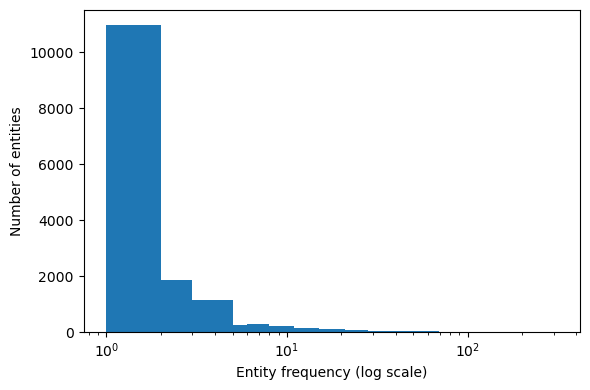

In [108]:
raw_frequencies_stats(drug_details)

In [109]:
drug_df, mapped_top10, unmapped_top10, side_by_side = top_mapped_unmapped_side_by_side(
    drug_details["unique_norm_to_id"],
    drug_details["norm_frequency"],
    entity_name="drug",
    unmapped_id="-1",
    top_n=10,
)

side_by_side


,Mapped Drug,Mapped Freq,Unmapped Drug,Unmapped Freq
0,placebo,330,antidepressant,151
1,levodopa,314,antipsychotic,107
2,risperidone,299,antidepressants,78
3,ketamine,253,antipsychotics,71
4,dexmedetomidine,234,ssri,69
5,olanzapine,227,selective serotonin reuptake inhibitor,45
6,aripiprazole,215,ssris,39
7,botulinum toxin type a,201,atypical antipsychotic,35
8,"fatty acids, omega-3",181,aeds,34
9,cannabidiol,178,dopamine agonist,33


## Disease entities

In [110]:
clinical_disesases = "/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/04_normalization/data/mapped_all/mapped_clinical_data_mondo_cleaned_with_mondo_parents.csv"
preclinical_disesases = "/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/04_normalization/data/mapped_all/mapped_preclinical_data_mondo_cleaned_with_mondo_parents.csv"

In [111]:
df_dis_cli = pd.read_csv(clinical_disesases)
df_dis_cli = df_dis_cli[df_dis_cli['nct_id'].isin(included_nctids['nct_id'])]
df_dis_cli.shape

(18609, 13)

In [112]:
df_dis_pre = pd.read_csv(preclinical_disesases)
df_dis_pre.shape

(540999, 13)

In [113]:
df_dis_pre.head()

,PMID,unique_conditions_linkbert_predictions,linkbert_mondo_predictions,disease_mondo_termid,disease_mondo_term_norm,disease_mondo_closest_3,disease_mondo_cdist,disease_term_mondo_clean,disease_termid_mondo_clean,nearest_dataset_parent_mondo,nearest_dataset_parent_label,merged_mondo_termid,merged_mondo_label
0,31733831,asthma,asthma,MONDO:0004979,asthma,"[['asthma', 'MONDO:0004979'], ['asthma, bronch...",0.0068,asthma,MONDO:0004979,-1,-1,MONDO:0004979,asthma
1,31733833,myocardial infarction,myocardial infarction,MONDO:0005068,myocardial infarction,"[['myocardial infarction', 'MONDO:0005068'], [...",0.0,myocardial infarction,MONDO:0005068,-1,-1,MONDO:0005068,myocardial infarction
2,31733925,systemic lupus erythematosus,systemic lupus erythematosus,MONDO:0007915,systemic lupus erythematosus,"[['systemic lupus erythematosus', 'MONDO:00079...",0.0,systemic lupus erythematosus,MONDO:0007915,-1,-1,MONDO:0007915,systemic lupus erythematosus
3,31733940,cognitive impairment,cognitive disorder,MONDO:0002039,cognitive disorder,"[['cognitive disorder', 'MONDO:0002039'], ['co...",7.6573,cognitive disorder,MONDO:0002039,-1,-1,MONDO:0002039,cognitive disorder
4,31734027,cumulative peripheral neuropathy|oxaliplatin-i...,cumulative peripheral neuropathy|oxaliplatin-i...,-1|-1|MONDO:0003620,cumulative peripheral neuropathy|oxaliplatin-i...,"[['chronic acquired peripheral neuropathy', 'M...",9.8837|13.0604|0.0055,cumulative peripheral neuropathy|oxaliplatin-i...,-1|-1|MONDO:0003620,-1,-1,-1|-1|MONDO:0003620,cumulative peripheral neuropathy|oxaliplatin-i...


### preclinical

In [114]:
doc_id_col = "PMID"
disease_raw_entities_col = "unique_conditions_linkbert_predictions"

disease_linked_entities_col = "disease_mondo_term_norm"
disease_linked_entities_ids = "disease_mondo_termid"

cleaned_mondo_entities = "disease_term_mondo_clean"

disease_parent_entities_col = "nearest_dataset_parent_label"
disease_with_parents_entities_col = "merged_mondo_label"
disease_with_parents_entities_ids = "merged_mondo_termid"

cols_to_keep = [
    doc_id_col,
    disease_raw_entities_col,
    disease_linked_entities_col,
    disease_linked_entities_ids,
    cleaned_mondo_entities,
    disease_parent_entities_col,
    disease_with_parents_entities_col,
    disease_with_parents_entities_ids,
]
df_to_analyse_disease_preclin = df_dis_pre[cols_to_keep].copy()
df_to_analyse = df_to_analyse_disease_preclin.copy()
df_to_analyse.head()

,PMID,unique_conditions_linkbert_predictions,disease_mondo_term_norm,disease_mondo_termid,disease_term_mondo_clean,nearest_dataset_parent_label,merged_mondo_label,merged_mondo_termid
0,31733831,asthma,asthma,MONDO:0004979,asthma,-1,asthma,MONDO:0004979
1,31733833,myocardial infarction,myocardial infarction,MONDO:0005068,myocardial infarction,-1,myocardial infarction,MONDO:0005068
2,31733925,systemic lupus erythematosus,systemic lupus erythematosus,MONDO:0007915,systemic lupus erythematosus,-1,systemic lupus erythematosus,MONDO:0007915
3,31733940,cognitive impairment,cognitive disorder,MONDO:0002039,cognitive disorder,-1,cognitive disorder,MONDO:0002039
4,31734027,cumulative peripheral neuropathy|oxaliplatin-i...,cumulative peripheral neuropathy|oxaliplatin-i...,-1|-1|MONDO:0003620,cumulative peripheral neuropathy|oxaliplatin-i...,-1,cumulative peripheral neuropathy|oxaliplatin-i...,-1|-1|MONDO:0003620


In [115]:
df_to_analyse["no_valid_mapping"] = (
    df_to_analyse["disease_mondo_termid"].apply(no_linked_entities)
)
perc_no_mapping_at_all = df_to_analyse.no_valid_mapping.sum()/len(df_to_analyse)*100
df_to_analyse.no_valid_mapping.sum(), 100 - perc_no_mapping_at_all

(70447, 86.97834931303015)

In [116]:
df_to_analyse = add_unique_entity_count(
    df_to_analyse,
    col="merged_mondo_label"
)
summary = summarize_entities_per_document(
    df_to_analyse,
    col="merged_mondo_label_unique_count"
)

summary

{'mean': 1.89, 'std': 1.18, 'median': 2.0, 'min': 1, 'max': 24}

In [117]:
disease_report, disease_details = entity_linking_report(
    df=df_to_analyse,
    ner_col=disease_raw_entities_col,  # raw
    norm_col=disease_linked_entities_col,                       # linked labels
    id_col=disease_linked_entities_ids,                            # linked ids (aligned)
    parent_label_col=disease_with_parents_entities_col,                 # linked + parent labels
    doc_id_col="PMID",
    clean_label_col="disease_term_mondo_clean",
)
disease_report

Only entities with more than 2 characters are considered.


,total mentions,count unique raw entities,count unique linked entities,count unique linked with parent,Linking success (unique / % mapped freq adjusted),mismatch rows (raw vs id length),count unique clean labels
0,1035001,123494,80123,79683,51158 (41.43%)/123494 (73.93%),0,79672


Entities appearing once: 82,091
Total unique entities: 123,494
Percentage singletons: 66.47%
Non-linked entities appearing once: 52,283 / 72,336 (72.28%)
Singletons linked: 29,808 / 82,091 (36.31%)
Entities of length smaller than 3: 0 
Short entities linked: 0 / 0 (0.00%)
Example singleton entities:
 - hev-associated neuroinflammation mapped to -1
 - prolonged bleeding mapped to -1
 - paracetamol-induced oxidative stress mapped to -1
 - hydrophila-associated infections mapped to MONDO:0005117
 - subacute neuronal death mapped to -1
 - ir)-induced oxidative injury mapped to -1
 - tail radionecrosis mapped to -1
 - chronic intestinal helminth infection mapped to -1
 - cerebellar infarction mapped to -1
 - core lesions mapped to -1
Example short entities:
1–2: 82091
2–3: 14960
3–5: 10194
5–7: 4277
7–12: 4342
12–20: 2709
20–34: 1732
34–56: 1106
56–92: 755
92–152: 489
152–252: 309
252–416: 215
416–688: 121
688–1137: 88
1137–1880: 48
1880–3108: 23
3108–5137: 21
5137–8492: 10
8492–14037: 3
14

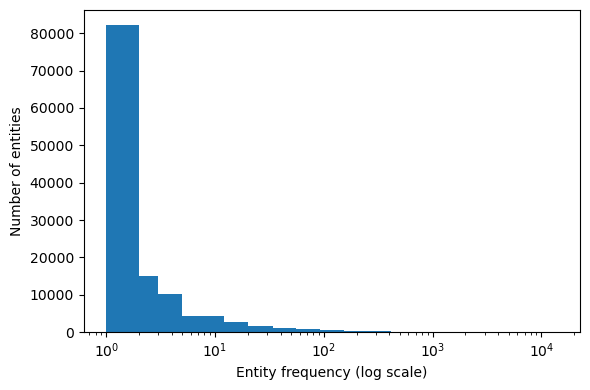

In [119]:
raw_frequencies_stats(disease_details)

In [120]:
disease_df, mapped_top10, unmapped_top10, side_by_side = top_mapped_unmapped_side_by_side(
    disease_details["unique_norm_to_id"],
    disease_details["norm_frequency"],
    entity_name="disease",
    unmapped_id="-1",
    top_n=10,
)
side_by_side

,Mapped Disease,Mapped Freq,Unmapped Disease,Unmapped Freq
0,ischemia reperfusion injury,23708,hypoxia,4331
1,epilepsy,19368,liver,2650
2,alzheimer disease,17855,stress,2445
3,diabetes mellitus,15451,oxidative stress,2296
4,ischemic disease,13451,focal cerebral ischemia,1904
5,parkinson disease,11941,i/r injury,1673
6,depressive disorder,10105,liver injury,1667
7,cerebral infarction,8911,hyperalgesia,1612
8,stroke disorder,8329,septic shock,1417
9,neuralgia,8197,shock,1412


In [121]:
mapped_diseases_to_ner_df = disease_details["mapped_to_ner_df"]
mapped_diseases_to_ner_df


,entity_mapping,entity,mapping,ner_tokens,ner_count
0,ischemia reperfusion injury (MONDO:0005203),ischemia reperfusion injury,MONDO:0005203,"[(i))-reperfusion, / reperfusion injury, / rep...",1378
1,perinatal asphyxia (MONDO:0006663),perinatal asphyxia,MONDO:0006663,"[acute asphyxia, acute hypoxic-ischemic (hi) e...",467
2,brain hypoxia - ischemia (MONDO:0006685),brain hypoxia - ischemia,MONDO:0006685,"[acute brain hypoxia, acute cerebral hypoxia, ...",302
3,brain ischemia (MONDO:0005299),brain ischemia,MONDO:0005299,"[acute and chronic brain ischemia, acute and c...",207
4,type 2 diabetes mellitus (MONDO:0005148),type 2 diabetes mellitus,MONDO:0005148,"[1 and 2 diabetes, 1 and 2 diabetic, 2 diabete...",184
...,...,...,...,...,...
7783,perichondritis of auricle (MONDO:0002246),perichondritis of auricle,MONDO:0002246,[perichondritis of],1
7784,osteopenia-intellectual disability-sparse hair...,osteopenia-intellectual disability-sparse hair...,MONDO:0009814,[oestrogen-deficiency osteopaenia],1
7785,disorder of sphingolipid biosynthesis (MONDO:0...,disorder of sphingolipid biosynthesis,MONDO:0021130,[sphingolipid disorders],1
7786,mucopolysaccharidosis or mucopolysaccharidosis...,mucopolysaccharidosis or mucopolysaccharidosis...,MONDO:0100365,[mucopolysaccharidosis-like disease],1


In [122]:
mapped_diseases_to_ner_df.to_csv("./data/linked_diseases_preclinical.csv", index=False)

### clinical

In [123]:
doc_id_col = "nct_id"

cols_to_keep = [
    doc_id_col,
    disease_raw_entities_col,
    disease_linked_entities_col,
    disease_linked_entities_ids,
    cleaned_mondo_entities,
    disease_parent_entities_col,
    disease_with_parents_entities_col,
    disease_with_parents_entities_ids,
]
df_to_analyse_cli_disease = df_dis_cli[cols_to_keep].copy()
df_to_analyse = df_to_analyse_cli_disease.copy()
df_to_analyse.head()

,nct_id,unique_conditions_linkbert_predictions,disease_mondo_term_norm,disease_mondo_termid,disease_term_mondo_clean,nearest_dataset_parent_label,merged_mondo_label,merged_mondo_termid
0,NCT03502551,suicidal|suicidal ideation|Suicide,suicidal|suicidal ideation|Suicide,-1|-1|-1,suicidal|suicidal ideation|Suicide,-1,suicidal|suicidal ideation|Suicide,-1|-1|-1
1,NCT05216770,laryngeal dystonia|voice tremor|Tremor,spasmodic dystonia|voice tremor|obsolete rare ...,MONDO:0000485|-1|MONDO:0017644,spasmodic dystonia|voice tremor|obsolete rare ...,focal dystonia|-1,spasmodic dystonia|voice tremor|obsolete rare ...,MONDO:0000485|-1|MONDO:0017644|MONDO:0000477
2,NCT03348735,np|subacute|pain|localized neuropathic pain|ch...,np|subacute|obsolete disorder involving pain|l...,-1|-1|MONDO:0021668|-1|MONDO:0021667|MONDO:002...,np|subacute|obsolete disorder involving pain|l...,-1|-1,np|subacute|obsolete disorder involving pain|l...,-1|-1|MONDO:0021668|-1|MONDO:0021667
3,NCT05995600,systemic lupus|definite|antiphospholipid syndr...,systemic lupus erythematosus|definite|antiphos...,MONDO:0007915|-1|-1|MONDO:0005098|-1|MONDO:000...,systemic lupus erythematosus|definite|antiphos...,-1|-1|-1|-1|-1|brain ischemia,systemic lupus erythematosus|definite|antiphos...,MONDO:0007915|-1|-1|MONDO:0005098|-1|MONDO:000...
4,NCT02137993,schizophreniform disorder|schizoaffective diso...,schizophreniform disorder|schizophrenia|schizo...,MONDO:0001265|MONDO:0005090|MONDO:0005090,schizophreniform disorder|schizophrenia,-1|-1,schizophreniform disorder|schizophrenia,MONDO:0001265|MONDO:0005090


In [124]:
df_to_analyse["no_valid_mapping"] = (
    df_to_analyse["disease_mondo_termid"].apply(no_linked_entities)
)
perc_no_mapping_at_all = df_to_analyse.no_valid_mapping.sum()/len(df_to_analyse)*100
df_to_analyse.no_valid_mapping.sum(), 100 - perc_no_mapping_at_all

(379, 97.96335106668816)

In [125]:
df_to_analyse = add_unique_entity_count(
    df_to_analyse,
    col="merged_mondo_label"
)
summary = summarize_entities_per_document(
    df_to_analyse,
    col="merged_mondo_label_unique_count"
)

summary

{'mean': 2.96, 'std': 1.99, 'median': 2.0, 'min': 1, 'max': 31}

In [126]:
(123919 - 80349)/123919

0.3516006423550868

In [127]:
disease_report, disease_details = entity_linking_report(
    df=df_to_analyse,
    ner_col=disease_raw_entities_col,  # raw
    norm_col=disease_linked_entities_col,                       # linked labels
    id_col=disease_linked_entities_ids,                            # linked ids (aligned)
    parent_label_col=disease_with_parents_entities_col,                 # linked + parent labels
    doc_id_col="nct_id",
    clean_label_col="disease_term_mondo_clean",
)
disease_report

Only entities with more than 2 characters are considered.


,total mentions,count unique raw entities,count unique linked entities,count unique linked with parent,Linking success (unique / % mapped freq adjusted),mismatch rows (raw vs id length),count unique clean labels
0,59361,15324,10818,10860,6558 (42.8%)/15324 (69.96%),0,10751


Entities appearing once: 11,048
Total unique entities: 15,508
Percentage singletons: 71.24%
Example singleton entities:
 - videoassisted thoracic surgery
 - mildly to moderately depressed
 - myeloproliferative disorders
 - contraceptive implant users
 - newly diagnosed or relapsing gca
 - arsenical cancers
 - c9orf72 mutation
 - cleft lip surgery
 - un
 - alzheimer's'disease
1–2: 11048
2–3: 1810
3–5: 1098
5–7: 457
7–10: 322
10–15: 240
15–22: 170
22–32: 111
32–47: 95
47–69: 57
69–101: 30
101–149: 28
149–219: 20
219–322: 9
322–473: 2
473–695: 5
695–1022: 4
1022–1502: 1
1502–1503: 1


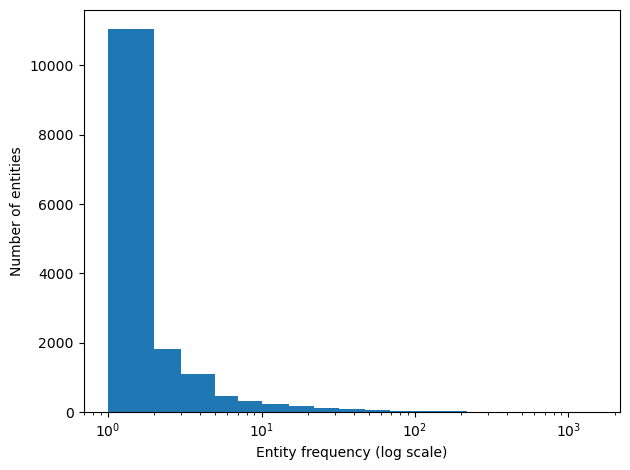

In [83]:
raw_frequencies_stats(disease_details)

In [51]:
disease_df, mapped_top10, unmapped_top10, side_by_side = top_mapped_unmapped_side_by_side(
    disease_details["unique_norm_to_id"],
    disease_details["norm_frequency"],
    entity_name="disease",
    unmapped_id="-1",
    top_n=10,
)
side_by_side

,Mapped Disease,Mapped Freq,Unmapped Disease,Unmapped Freq
0,Alzheimer disease,1999,mild to moderate alzheimer's disease,205
1,schizophrenia,1917,smoking,184
2,depressive disorder,1780,fatigue,160
3,Parkinson disease,1713,mild cognitive impairment,146
4,bipolar disorder,1061,cocaine,134
5,stroke disorder,924,spasticity,108
6,epilepsy,915,agitation,101
7,migraine disorder,897,surgery,91
8,obsolete disorder involving pain,856,smokers,90
9,multiple sclerosis,736,postoperative delirium,75


# Combine entities

In [65]:
df_to_analyse_preclin = df_to_analyse_disease_preclin.merge(df_to_analyse_drug_preclin, on="PMID")

In [67]:
df_to_analyse_preclin.to_csv("data/entities_drug_disease_preclin.csv", index=False)

In [91]:
df_to_analyse_clin = df_to_analyse_cli_disease.merge(df_to_analyse_cli_drugs, on="nct_id")

In [93]:
df_to_analyse_clin.to_csv("data/entities_drug_disease_clin.csv", index=False)